# Blood Pressure Estimation with Neural Networks

In this notebook it is possible to find a tutorial on how to employ the trained neural-network-based model.
The netobook resume the trained model and simply run inference on a sample from the test set. The purpose is only to clarify how the model should be utilized inside an application.

![Model Inference Visualization](continuous_abp_inference.jpg)

## Setup Environment

In [30]:
import os
import sys
import yaml
module_path = os.path.abspath(os.path.join('..', 'data'))
if module_path not in sys.path:
    sys.path.append(module_path)
module_path = os.path.abspath(os.path.join('..', 'models'))
if module_path not in sys.path:
    sys.path.append(module_path)
module_path = os.path.abspath(os.path.join('..', 'training_utils'))
if module_path not in sys.path:
    sys.path.append(module_path)
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from data.dataset import PhysioDataset
from models.UNet import UNet

In [10]:
# Load the YAML configuration file to get the trianing configuration
# N.B. replace path with the actual path to your checkpoint/YAML file

checkpoint_path = '/home/michele/Documents/ContinualBP/checkpoints/unet/unet-UNet-2025_05_28-23_19_19/unet/ckpt/UNet'
config_file_path = '/home/michele/Documents/ContinualBP/checkpoints/unet/unet-UNet-2025_05_28-23_19_19/unet/ckpt/config.yaml'  
dataset_path = '/home/michele/Documents/ContinualBP/data/lmdb/mimic_iii'

with open(config_file_path, 'r') as file:
    config = yaml.safe_load(file)

# Print the loaded configuration to verify
print(config)

 # Select the gpu to be usesd
os.environ['CUDA_VISIBLE_DEVICES'] = "0"
device = torch._C.device("cuda:0")

{'aug': False, 'batch_size': 128, 'bidirectional': True, 'channels': '32, 64, 128, 256, 512', 'checkpoint_path': './checkpoints/unet/unet-UNet-2025_05_28-23_19_19', 'criterion': 'SmoothL1Loss', 'dataset_folder': './data/lmdb', 'dataset_name': 'mimic_iii', 'dim_feedforward': 128, 'dim_feedforward_attention': 128, 'ecg': True, 'embed_dim': 32, 'enable_amp': False, 'es_enable': False, 'es_min_delta': 0.01, 'es_patience': 10, 'eval_every_n_epochs': 1, 'expname': 'unet', 'figure_path': './figs/unet/unet-UNet-2025_05_28-23_19_19', 'fold': 0, 'fs': 125, 'gpu': '0', 'hidden_dim': 128, 'input_seq_len_s': 5, 'kernel_size': 3, 'l2norm': 0.001, 'lambda_contrastive': 0.0, 'lambda_ortho': 0.0, 'lambda_supervised': 1.0, 'loader_worker': 4, 'lr': 0.001, 'lr_linear_probe': 0.0005, 'lr_personalization': 0.0005, 'lr_scheduler_enable': True, 'lr_scheduler_min_lr': 0.0001, 'lr_scheduler_type': 'ExponentialLR', 'lr_scheduler_warmup': 0, 'lrsched_gamma': 0.5, 'lrsched_step': '5, 10, 15, 20, 40', 'max_trainin

## Load Dataset

In [14]:
dataset = PhysioDataset(
        seed=config['seed'],
        lmdb_folder=dataset_path,
        pretraining_ratio=config['pretraining_ratio'],
        pretraining_split_ratio=list(map(float, config['pretraining_tr_val_tt_split_ratio'].split(','))),
        personalization_sample_number=config['personalization_sample_number'],
        mix_pretraining_subject_samples=config['mix_pretraining_subject_samples'],
        fs=config['fs'],
        input_seq_len_s=config['input_seq_len_s'],
        ecg=config['ecg'],
        resp=config['resp'],
        sig2sig=config['sig2sig'],
        ppg_derivatives=config['ppg_derivatives'],
        ppg_emd=config['ppg_emd'],
        ppg_freqs=config['ppg_freqs']
    )

 # Get train/val/test samplers and build the dataloaders
(train_sampler, val_sampler, test_sampler) = dataset.get_pretraining_samplers()

test_dataloader = torch.utils.data.DataLoader(dataset, sampler=test_sampler, batch_size=config['batch_size'], num_workers=config['loader_worker'], pin_memory=True)

PhysioDataset initialized with following configuration:
{'Pretraining Ratio': 0.8,
 'Samples': 594333,
 'Subjects': {'Personalization': 305, 'Pretraining': 1219, 'Total': 1524}}
PhysioDataset get_pretraining_samplers
Pretraining train/val/test sets samples are sampled from the same subject set
{'Pretraining Samples (# per split)': {'Test': 95084,
                                       'Train': 332765,
                                       'Valid': 47534}}


## Load Model

In [23]:
model = UNet(
        ecg=config['ecg'],
        resp=config['resp'],
        sig2sig=config['sig2sig'],
        ppg_derivatives=config['ppg_derivatives'],
        ppg_emd=config['ppg_emd'],
        ppg_freqs=config['ppg_freqs'],
        fs=config['fs'],
        input_seq_len_s=config['input_seq_len_s'],
        channels=config['channels'],
        kernel_size=config['kernel_size'],
        num_heads_attention=config['num_heads_attention'],
        dim_feedforward_attention=config['dim_feedforward_attention']
        )
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model.load_state_dict(checkpoint['model'])
model.eval()
model = model.to(device)

# Test Model

In [47]:
def plot_signals(signals, fs, labels=None, title='', savepath=None, ylabels=None, 
                 targets=None, outputs=None, figsize=(15, 10)):
    """
    Plots input signals in separate subplots and target vs output in a third subplot using seaborn styling.
    
    Parameters
    ----------
    signals : array-like
        Input signals with shape [num_channels, sequence_length] 
        Expected: [2, 625] (transposed from original [625, 2])
    fs : float
        Sampling frequency for time axis calculation
    labels : list, optional
        Labels for each signal channel (e.g., ['PPG', 'ECG'])
    title : str, optional
        Main title for the entire figure
    savepath : str, optional
        Directory path to save the plot. If None, plot is not saved.
    ylabels : list, optional
        Y-axis labels for each signal (e.g., ['a.u.', 'mV'])
    targets : array-like, optional
        Target signal for comparison plotting
    outputs : array-like, optional
        Model output signal for comparison plotting
    figsize : tuple, default=(15, 10)
        Figure size (width, height)
        
    Returns
    -------
    fig : matplotlib.figure.Figure
        The created figure object
    """
    
    # Set seaborn style with pastel colors
    sns.set_style("whitegrid")
    sns.set_palette("pastel")
    
    # Get pastel colors for consistent styling
    colors = sns.color_palette("pastel", n_colors=10)
    
    # Convert to numpy arrays if needed
    signals = np.array(signals)
    
    # Create time axis
    num_samples = signals.shape[0]  # 625
    time_axis = np.arange(num_samples) / fs
    
    # Determine number of subplots (2 for input signals + 1 for target/output if provided)
    num_plots = 3 if (targets is not None and outputs is not None) else 2
    
    # Create figure and subplots
    fig, axes = plt.subplots(num_plots, 1, figsize=figsize)
    if num_plots == 1:
        axes = [axes]
    
    # Set default labels if not provided
    if labels is None:
        labels = [f'Signal {i+1}' for i in range(signals.shape[1])]
    if ylabels is None:
        ylabels = ['Amplitude'] * signals.shape[0]
    
    # Plot input signals in separate subplots
    for i in range(min(2, signals.shape[1])):  # Plot first 2 channels
        axes[i].plot(time_axis, signals[:, i], color=colors[i], linewidth=2, alpha=0.8)
        axes[i].set_title(f'{labels[i]} Signal', fontsize=14, fontweight='bold')
        axes[i].set_ylabel(ylabels[i], fontsize=12)
        axes[i].grid(True, alpha=0.3)
        axes[i].set_xlim(0, time_axis[-1])
        
        # Add subtle background
        axes[i].set_facecolor('#fafafa')
    
    # Plot target vs output comparison if provided
    if targets is not None and outputs is not None and num_plots == 3:
        # Plot target and output
        axes[2].plot(time_axis, targets, color=colors[2], linewidth=3, 
                    label='Target', alpha=0.8)
        axes[2].plot(time_axis, outputs, color=colors[3], linewidth=3, 
                    label='Predicted', alpha=0.8, linestyle='--')
        
        axes[2].set_title('Target vs Predicted', fontsize=14, fontweight='bold')
        axes[2].set_ylabel('mmHg', fontsize=12)
        axes[2].legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
        axes[2].grid(True, alpha=0.3)
        axes[2].set_facecolor('#fafafa')
    
    # Set x-label for the bottom subplot
    axes[-1].set_xlabel('Time (s)', fontsize=12)
    
    # Set main title
    if title:
        fig.suptitle(title, fontsize=16, fontweight='bold', y=0.95)
    
    # Adjust layout
    plt.tight_layout()
    if title:
        plt.subplots_adjust(top=0.92)
    
    # Save plot if path is provided
    if savepath is not None:
        import os
        filename = 'original_vs_reconstructed.png'
        full_path = os.path.join(savepath, filename)
        plt.savefig(full_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Plot saved to: {full_path}")
    
    return fig


In [59]:
def plot_abp_signal(signal):
    """
    Plots an Arterial Blood Pressure (ABP) signal.

    Args:
        signal (numpy.ndarray or torch.Tensor): The ABP signal of shape [625].
    """
    if isinstance(signal, torch.Tensor):
        signal = signal.cpu().numpy()

    if signal.shape != (625,):
        raise ValueError("Input signal must have a shape of [625]")

    fs = 125  # Sampling frequency (assuming from the UNet.py and SSLUNet.py files)
    time = np.arange(0, len(signal)) / fs

    plt.figure(figsize=(12, 6))
    sns.set_theme(style="white")

    # Use a pastel color palette
    pastel_color = sns.color_palette("pastel")[0] # Get the first color from the 'pastel' palette

    sns.lineplot(x=time, y=signal, color=pastel_color)

    plt.title("Arterial Blood Pressure (ABP) Signal")
    plt.xlabel("s")
    plt.ylabel("mmHg")
    plt.tight_layout()
    plt.savefig('./reconstructued_abp.jpg')
    plt.show()

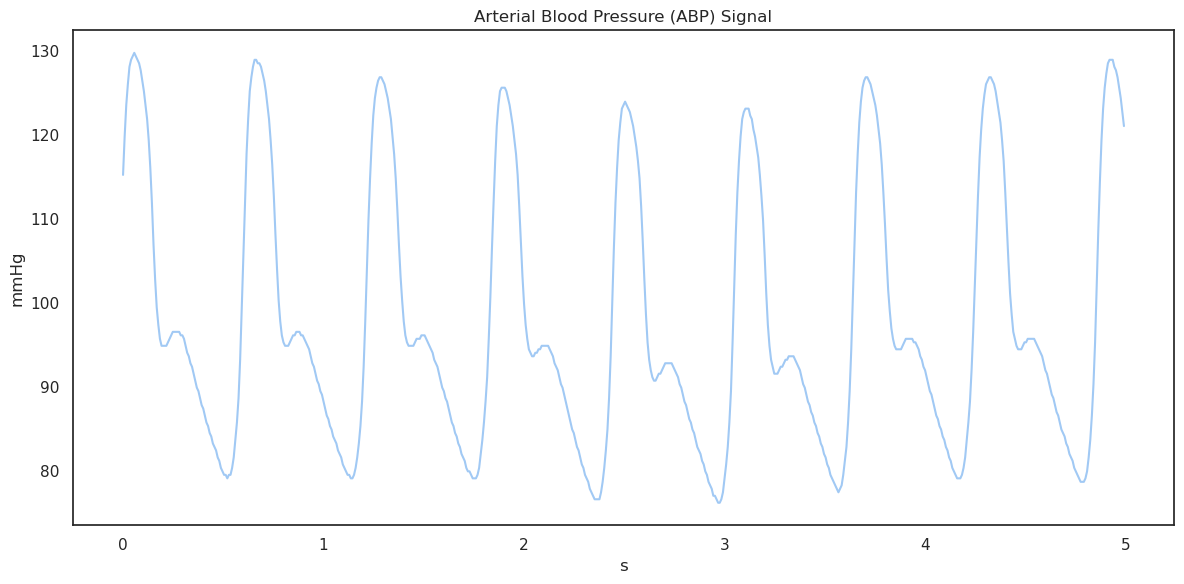

Plot saved to: ./original_vs_reconstructed.png


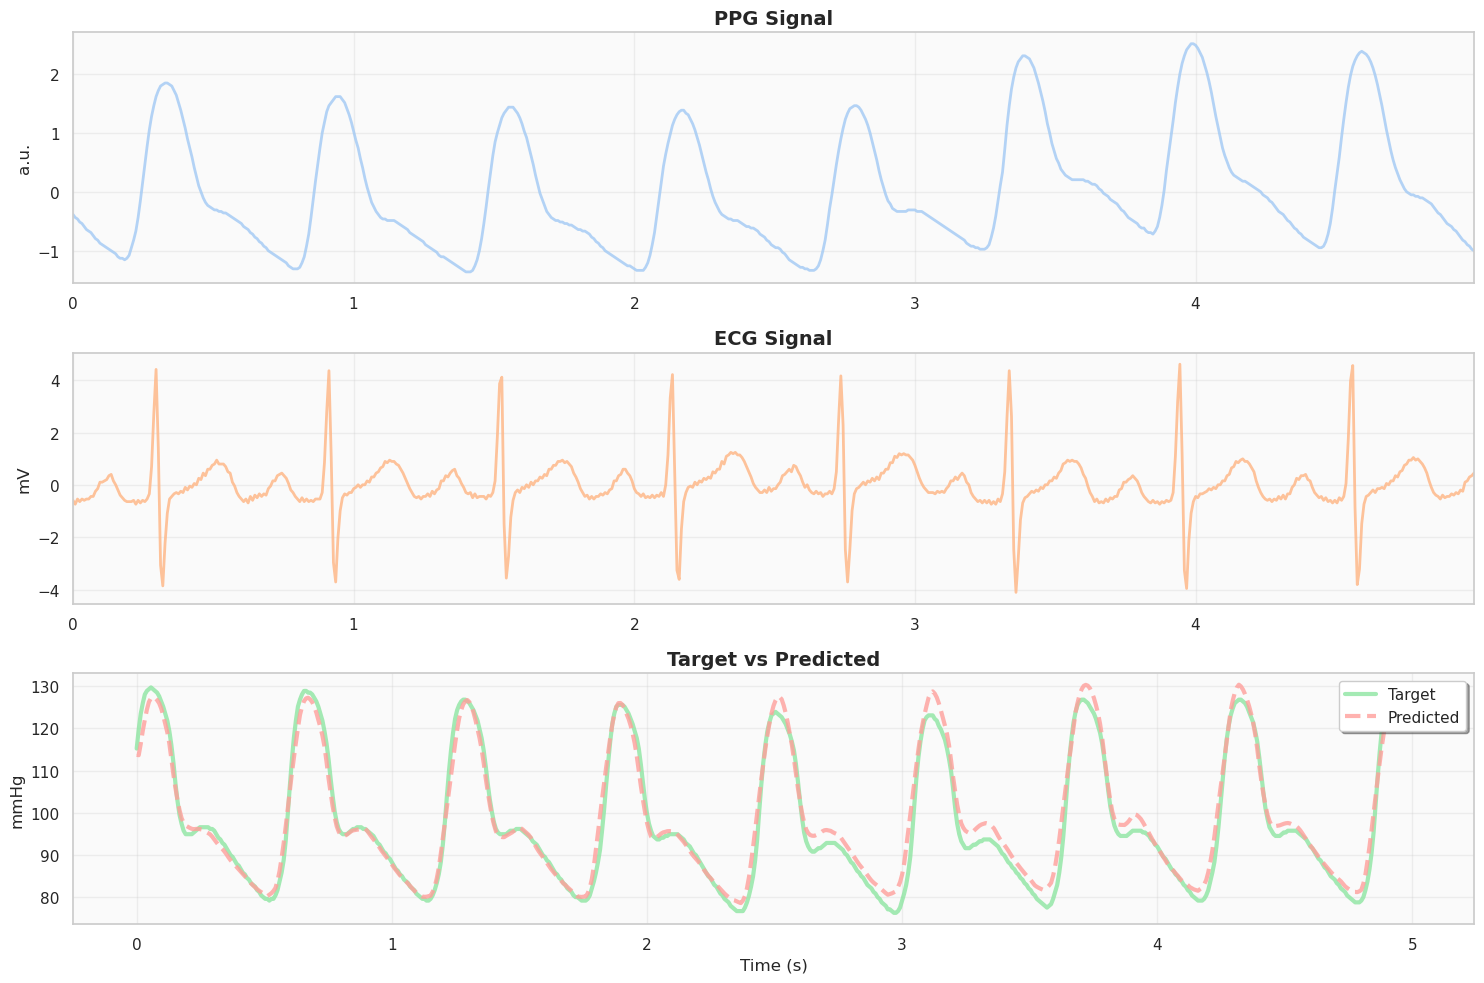

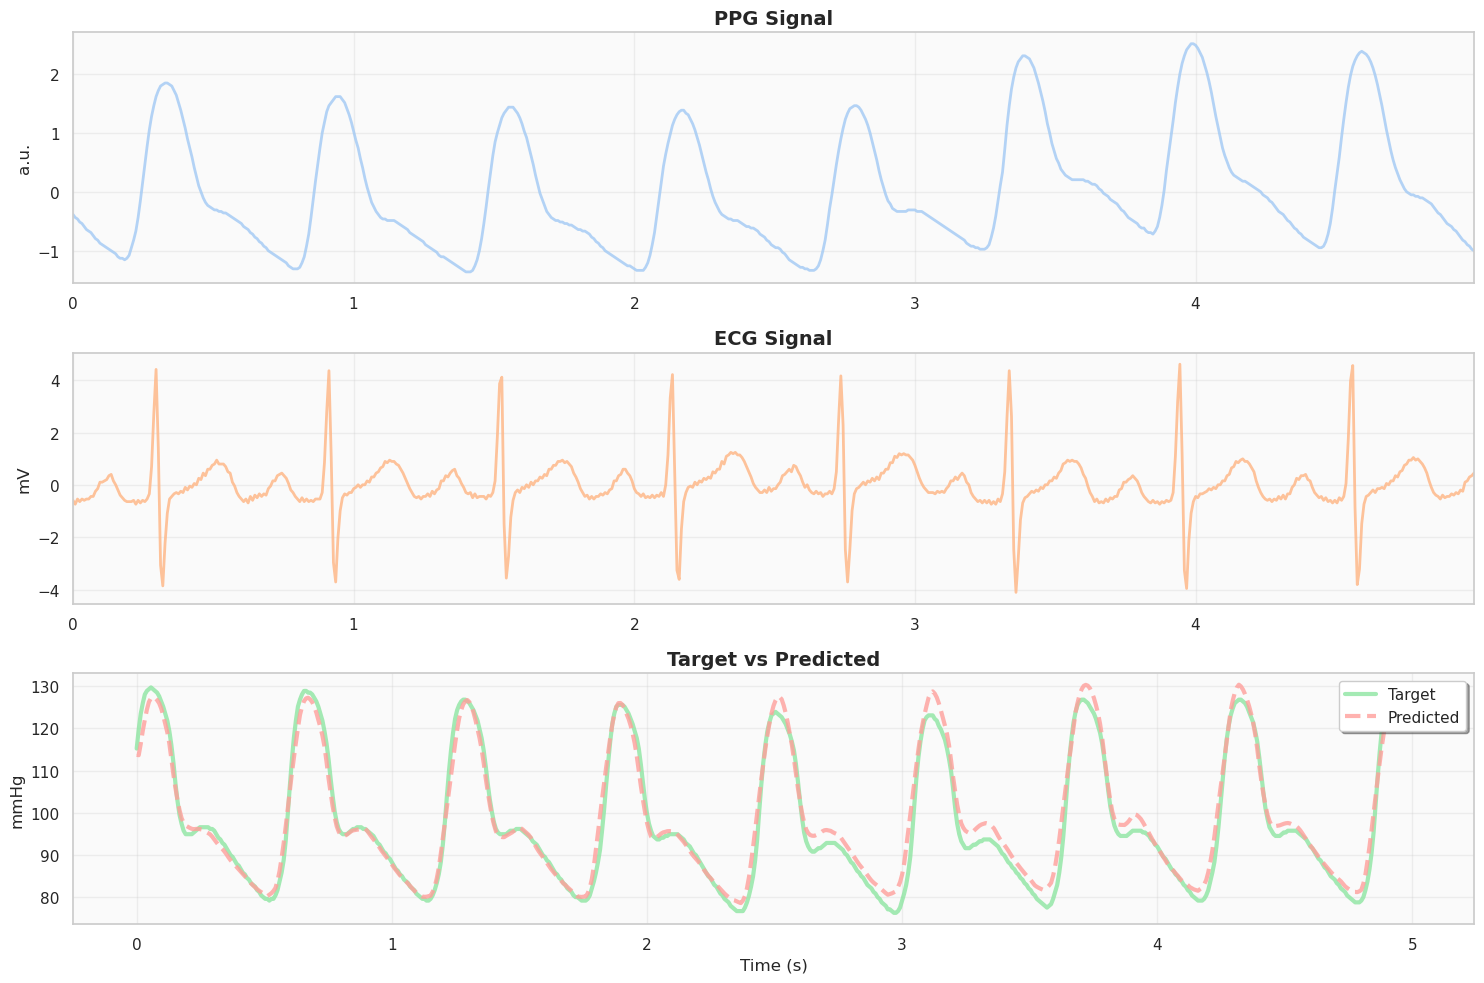

In [60]:
# Get a single batch from the test dataloader
batch = next(iter(test_dataloader))

# Extract signals and targets from the batch
signals, targets = batch

# Move data and labels to the same device as the model
signals = signals.to(device)
targets = targets.to(device)

# Perform forward pass
outputs = model(signals)
    
# Visualize prediction results on a sample from the batch.
idx = 3  # Index of the sample to visualize

signals = signals.cpu().numpy()

targets = targets.cpu().numpy()
outputs = outputs.cpu().detach().numpy()

plot_abp_signal(targets[idx, :])

plot_signals(
            signals[idx, :, :], 
            fs=config['fs'], 
            labels=['PPG', 'ECG'],  
            savepath='./', 
            ylabels=['a.u.', 'mV'],
            targets=targets[idx, :],
            outputs=outputs[idx, :]
            )